# Image Deconstruction
This notebook is a basic example of how to use Google Nano Banana to convert new photos into old looking ones in Jupyter Notebook/Python.

Let's import the necessary libraries:

In [7]:
import os
from dotenv import load_dotenv
from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

load_dotenv("../../../_starter/.env")

True

### Start by setting up a client

In [8]:
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

# Reference persona image
To make edits to an image we will need to load an example that we can use as context.

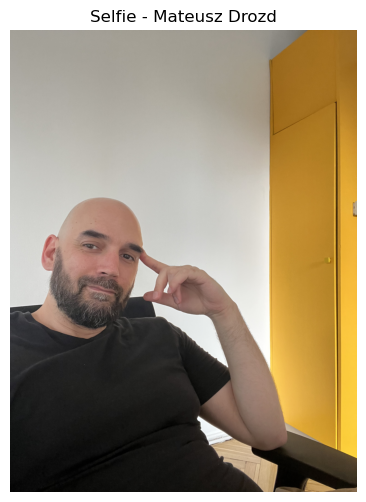

In [9]:
# Load the image
image_path = "../../assets/selfie_mateusz_drozd.jpeg"
image_persona = Image.open(image_path)

# Rotate the image
image_persona = image.rotate(-90, expand=True)

# Display image
plt.figure(figsize=(8, 6))
plt.imshow(image_persona)
plt.axis('off')
plt.title("Selfie - Mateusz Drozd")
plt.show()

# Reference style image
If we want to match a style of a specific image we can use LLM to describe its unique features.

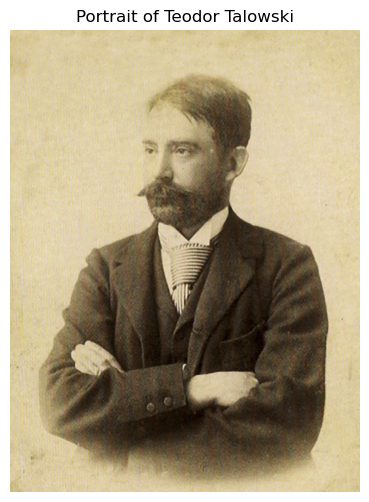

In [10]:
# Load the image
image_path = "../../assets/portrait_teodor_talowski.png"
image_style = Image.open(image_path)

# Display image
plt.figure(figsize=(8, 6))
plt.imshow(image_style)
plt.axis('off')
plt.title("Portrait of Teodor Talowski")
plt.show()

## Deconstruct the image
We can use Gemini 2.5 flash image preview to edit the image using a style reference.

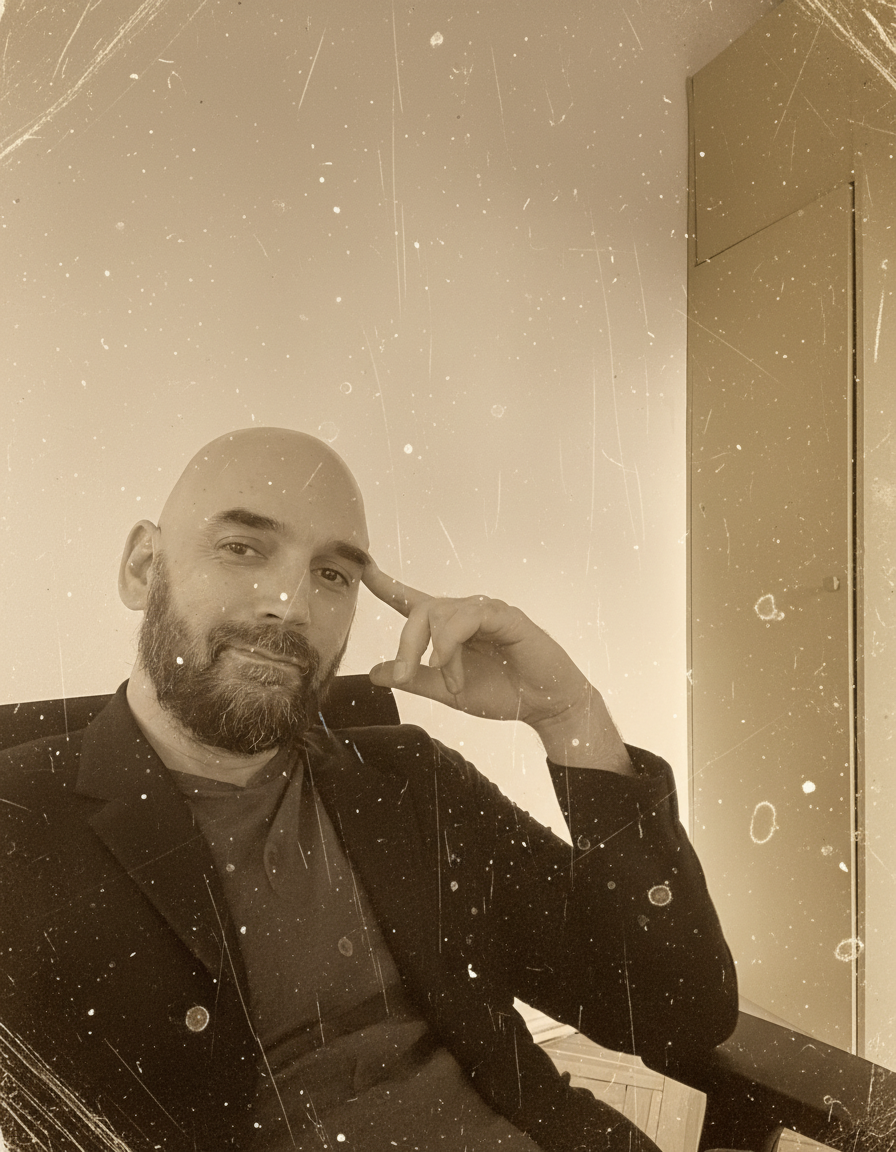

In [36]:
prompt = (
    "Rerender the modern image using the style from the old image"
    "Make sure to match the color scheme and highlight/shadow value"
    "Include all defects from the reference image"
    "Transfer all style details, including defects, scratches, dust, etc."
    "Feel free to loose details of the image prioritizing the style match"
    "Make the match as close as possible"
)

image = image_persona

response = client.models.generate_content(
    model="gemini-2.5-flash-image-preview",
    contents=[prompt, image_persona, image_style],
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO(part.inline_data.data))
        image.save("../../assets/selfie_mateusz_drozd_deconstructed.png")

image

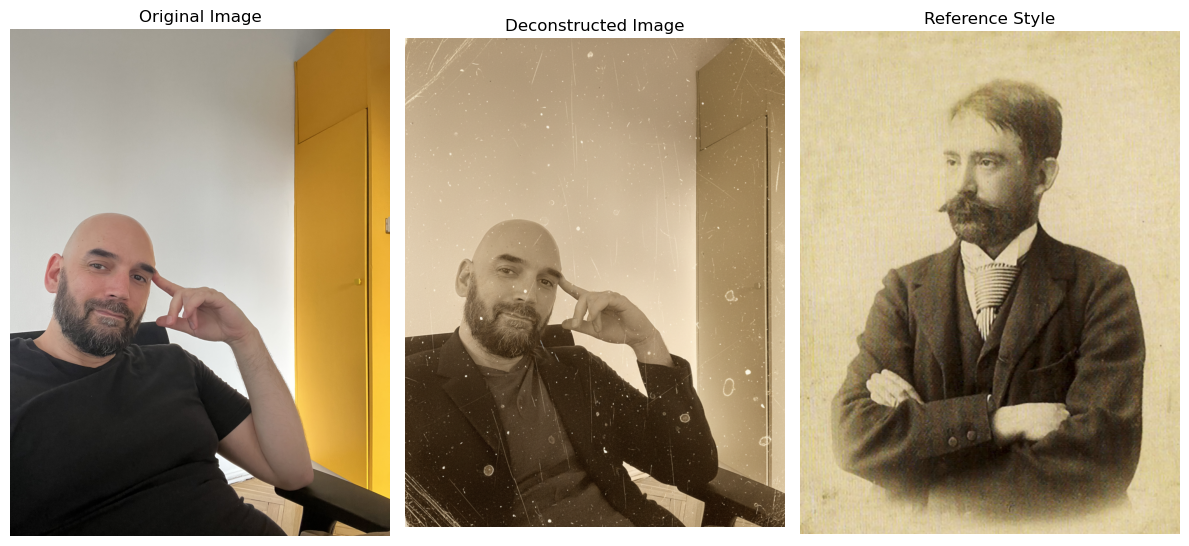

In [37]:
def show_images_side_by_side(image_paths, titles=None, figsize=(12, 6)):
    """
    Display multiple images side by side
    
    Args:
        image_paths: List of image file paths
        titles: List of titles for each image (optional)
        figsize: Figure size as tuple (width, height)
    """
    n_images = len(image_paths)
    
    # Create subplot grid
    fig, axes = plt.subplots(1, n_images, figsize=figsize)
    
    # Handle single image case
    if n_images == 1:
        axes = [axes]
    
    for i, (img_path, ax) in enumerate(zip(image_paths, axes)):
        # Load and display image
        img = Image.open("../../assets/"+img_path)

        # Rotate first image
        if i == 0:
            img = img.rotate(-90, expand=True)

        ax.imshow(img)
        ax.axis('off')
        
        # Add title if provided
        if titles and i < len(titles):
            ax.set_title(titles[i])
    
    plt.tight_layout()
    plt.show()

# Example usage
image_paths = ['selfie_mateusz_drozd.jpeg', 'selfie_mateusz_drozd_deconstructed.png', "portrait_teodor_talowski.png"]
titles = ['Original Image', 'Deconstructed Image', "Reference Style"]

show_images_side_by_side(image_paths, titles)